<a href="https://colab.research.google.com/github/ademiiskak126-ui/Diabetes_Prediction/blob/main/MoodShieldAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: unitary/toxic-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

                                       text sentiment toxicity
0  Сегодня отличный день, настроение супер!  POSITIVE    toxic
1                        Спасибо за помощь!  POSITIVE    toxic
2                          Это ужасный код!  POSITIVE    toxic
3                         Ты сделал ошибку!  POSITIVE    toxic


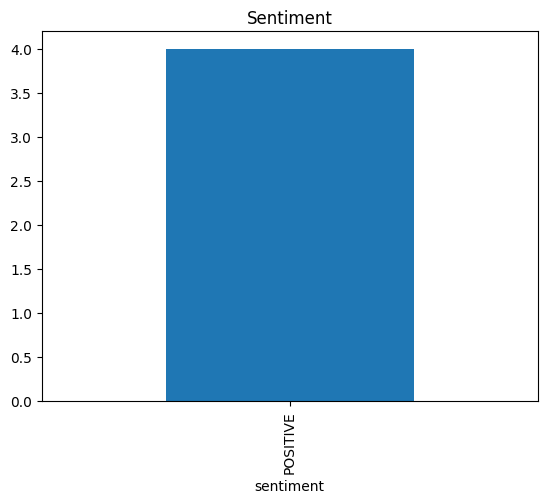

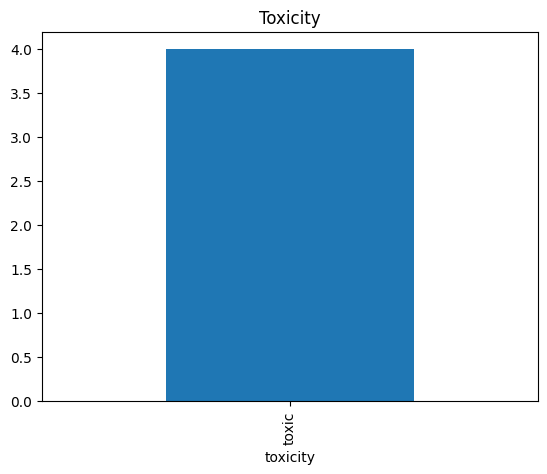

In [1]:
# =========================
# Установка библиотек
# =========================
!pip install -q transformers torch pandas matplotlib

# =========================
# Импорт библиотек
# =========================
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt

# =========================
# Отключение возможных widgets (ВАЖНО)
# =========================
import os
os.environ["DISABLE_WIDGETS"] = "1"

# =========================
# Создание CSV
# =========================
comments = ["Сегодня отличный день, настроение супер!", "Спасибо за помощь!", "Это ужасный код!", "Ты сделал ошибку!"]

df = pd.DataFrame(comments, columns=['text'])

# Сохраняем локально
csv_path = 'comments.csv'
df.to_csv(csv_path, index=False)

# =========================
# Загрузка данных
# =========================
df = pd.read_csv(csv_path)

# =========================
# Модели
# =========================
sentiment_classifier = pipeline('sentiment-analysis')
toxicity_classifier = pipeline("text-classification", model="unitary/toxic-bert")

# =========================
# Анализ
# =========================
results = []
for text in df['text']:
    sentiment = sentiment_classifier(text)[0]
    toxicity = toxicity_classifier(text)[0]

    results.append({
        "text": text,
        "sentiment": sentiment['label'],
        "toxicity": toxicity['label']
    })

df_results = pd.DataFrame(results)
print(df_results)

# =========================
# График 1
# =========================
df_results['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment")
plt.show()

# =========================
# График 2
# =========================
df_results['toxicity'].value_counts().plot(kind='bar')
plt.title("Toxicity")
plt.show()